# Applied Math 10: Computing for Science and Engineering


## Lab 10 : Second-order Ordinary Differential Equations (ODEs)

**Fall 2020**<br/>
<br>


### Learning Goals of Lab 
In this Lab, we continue the work started in lecture 10. Our objective is to:
- write python functions for the Euler and Runge-Kutta 2nd order (RK) methods of solving second order ODEs discussed in lecture 10
- solve interesting and practical second order ODEs.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### Coding functions for Euler's method (via three point formula for derivative)

A second-order ODE is then given by:

$$ \frac{d^2 u}{dx^2} = g(x,u,u') $$

where $g(u,u',x)$ is a given function of the function $u$, its first derivative $$u'=\frac{du}{dx}, $$ and the variable $x$.  We also need to know the value of the function $u(x)$ and its derivative $u'(x)$ for some specific value of $x$ (the "initial" or "boundary" conditions), so that we can try to solve for the function $u(x)$ that satisfies this equation. 

$$u'(x_{n+1})=u'(x_{n-1}) + 2 \; \Delta x \; g(x_n, u(x_n), u'(x_n)) ~~~~ (1)$$

$$u(x_{n+1})=u(x_{n-1}) + 2 \; \Delta x \; u'(x_n) ~~~~~~~~~~~~~~~~~~~~~~~~~~~ (2) $$


We will code these formulas with the replacements $\bf{u'}$ by $\bf{ud}$, $\bf{u}$ by $\bf{uf}$, and $\bf{g(x,u,u')}$ by $\bf{gf}$.

___________________________________________________________________________________________________________________________

**Exercise 1**: "Translate" the Euler formulas into code by completing the designated sections.

In [36]:
#Function to integrate a second-order ODE 
#Euler's method with three point formula for derivative
#-------------------------------------------------------------------------
#Note: We are using the following replacements in the formulae:
#    ud for u', uf for u, gf for g
#---------------------------------------------------------------------------

def ode2_euler(Nx,xmin,xmax,uf0,ud0):
    #Nx: Number of points to be used for integration.
    #xmin, xmax: Integration limits
    #uf0: Intial condition on uf at xmin
    #ud0: Initial condition on ud at xmin

    x = np.linspace(xmin, xmax, Nx)
    dx = x[1] - x[0]
    dx2=2.0*dx

    uf=np.zeros(Nx)
    ud=np.zeros(Nx)
    
    #Initial (boundary) conditions
    uf[0]=uf0
    ud[0]=ud0
    #We will write a separate python function for 
    # gf(x[n],uf[n],ud[n]) later. The initial value will be:

    gf0=gf(x[0],uf[0],ud[0])
    
    #Also:
    ud[1]=ud[0]+dx*gf0
    uf[1]=uf[0]+dx*ud[0]

    for n in range(1,Nx-1):
      '''Fill in the code for ud[n+1] and uf[n+1]'''
      '''Refer to Equations (1) and (2)'''
      #---------------------------------------------
      ud[n+1]=ud[n-1]+dx2*gf(x[n],uf[n],ud[n])
      uf[n+1]=uf[n-1]+dx2*ud[n]
      #----------------------------------------------
    return uf   

___________________________________________________________________________________________________________________________

### Function for the Runge-Kutta 2nd order method


Starting with second-order equation, 
we can break it up to a couple of first-order equations:

$$\frac{d^2 u}{d x^2} = g(x,u,u')$$

$$\frac{d u}{d x} = v 
\Rightarrow 
\frac{d v}{dx} = \frac{d^2 u}{d x^2} = g(u,v,x) $$

Now we deal with the two coupled first-order equations, and use the second-order RK method:

$$\frac{d u}{dx} = v, \; \; \; \frac{d v}{dx} = g(x,u,v)$$

$$k^{(1)}_n =v_n, \; \; \; l^{(1)}_n =g(x_n,u_n,v_n)$$

$$k^{(2)}_n=v_n+\frac{h l^{(1)}_n}{2},\; \; \; 
l^{(2)}_n=g(x_n+\frac{h}{2},u_n+\frac{h k^{(1)}_n}{2}, v_n+\frac{h l^{(1)}_n}{2} )$$ 

$$k^{(3)}_n = v_n+h l^{(2)}_n, \; \; \; 
l^{(3)}_n = g(x_n+h,u_n+h k^{(2)}_n, v_n+h l^{(2)}_n)
$$ 

$$u_{n+1} = u_n + \frac{h}{4} \left [ k^{(1)}_n + 2 \; k^{(2)}_n + k^{(3)}_n \right ], \; \; \; 
v_{n+1} = v_n + \frac{h}{4} \left [ l^{(1)}_n + 2 \; l^{(2)}_n + l^{(3)}_n 
\right ]
$$

We will code this with the following substitutions: $\bf{h}$ by $\bf{dx}$, $\bf{u}$ by $\bf{uf}$, $\bf{v}$ by $\bf{vf}$, $\bf{g(x,u,u')}$ by $\bf{gf}$, $\bf{f(x,u,u')}$ by $\bf{ff}$, $\bf{k_n^{(p)}}$ by $\bf{knp}$, $\bf{l_n^{(p)}}$ by $\bf{lnp}$ where $\bf{p}$ takes the values 1, 2, and 3.

___________________________________________________________________________________________________________________________

**Exercise 2**: "Translate" the Runge-Kutta formulas (RK2) into code by completing the designated sections.

In [22]:
def ode2_rk2(Nx, xmin, xmax, uf0, vf0):
    #Diff eqns of form: 
    #                 d(uf)/dx=ff(x,uf,vf)
    #                 d(vf)/dx=gf(x,uf,vf)
    #Nx: Number of points to be used for integration
    #xmin, xmax: Initial and final values of the independent variable (x)
    #uf0, vf0: Initial (boundary) values of the dependent variables at x=xmin
     
    x = np.linspace(xmin, xmax, Nx)
    dx = x[1] - x[0] # dx = h 
    
    uf = np.zeros(Nx) # uf = u 
    vf = np.zeros(Nx) # vf = v 
    
    #Initial conditions on u and v
    uf[0] = uf0
    vf[0] = vf0
    
    #We define two variables that minimize repetitive computations (such as multiplying or dividing dx by 2)
    #You can use these below while coding
    
    dxovr4 = dx / 4.0
    dxovr2 = dx / 2.0

    for n in range(Nx - 1):
        #We need to suppy the functions ff(x,uf,vf) and gf(x,uf,vf)
        
        #Formulae can be coded as:
        kn1 = ff(x[n], uf[n], vf[n]) 
        ln1 = gf(x[n], uf[n], vf[n])

        kn2 = ff(x[n] + dxovr2, uf[n] + dxovr2 * kn1, vf[n]+dxovr2 * ln1)
        ln2 = gf(x[n] + dxovr2, uf[n] + dxovr2 * kn1, vf[n]+dxovr2 * ln1)

        ''' Code remaining formulae'''
        #--------------------------------------------------------------------
        kn3 = ff(x[n] + dx, uf[n] + dx * kn2, vf[n]+dx * ln2)
        ln3 = gf(x[n] + dx, uf[n] + dx * kn2, vf[n]+dx * ln2)

             
        uf[n+1] = uf[n] + dxovr4 * (kn1 + 2.0 * kn2 + kn3)
        vf[n+1] = vf[n] + dxovr4 * (ln1 + 2.0 * ln2 + ln3)
        #-------------------------------------------------------------------
    return uf

___________________________________________________________________________________________________________________________

### Eigenfunction Problem 
We will now illustrate how to use the Euler and RK functions to solve the eigenfunction problem explained in Lecture 10. Note that this task has three parts:
1. We need to supply the functions `ff` (needed by RK) and `gf` (needed by both RK and Euler). You identify these by casting the ODE into a form discussed in Lecture 10.
2. We also need to supply the boundary (initial) conditions. 
3. We need to code the exact solution for comparison.

Steps (1) and (2) will be common to all problems. Step (3) is needed only if you know the exact solution  or, at least, an approximation to the exact solution.

#### Example

Solve the second-order ODE equation:

$$ \frac{d^2 u}{dx^2} = -a^2 u $$


$$(\Rightarrow g(x,u,u') = -a^2 u  )$$

with $\alpha = 2$ and initial conditions $u(0) = 1$, $\frac {du}{dx} (0) = 0 $.

For this problem, the general solution $u(x) = A \sin (a x) + B \cos (a x)$ becomes (for the specific boundary conditions and parameter values of this problem)  $u_{true}(x) = \cos (a x)$ (that is, $A = 0, B = 1$).

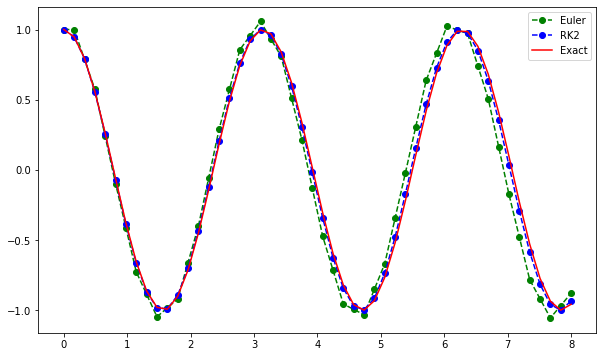

In [24]:
# Redo the sine/cosine function with the RK method
# g(x,u,v) = -a**2 u, f(x,u,v) = v
# Apply this for Nx=50 (initially), xmax=8.0. 

Nx=50
xmin=0.0
xmax=8.0
x=np.linspace(xmin,xmax,Nx)


a=2.0
Afact=1.0

uf0=Afact
ud0=0.0

#Define the functions gf and ff. 
#These are called from within the Euler and RK functions. They need to have the
#same names as used in those functions.They need to have the same number of arguments.
#The variable names can be different.

def gf(x,uf,ud):
    a=2.0
    asq=a**2
    return -asq*uf

def ff(x,uf,ud):
    return ud

# The "general" solution in terms of the boundary conditions
Aconst=ud0/a
Bconst=uf0
utrue=Aconst*np.sin(a*x)+Bconst*np.cos(a*x)

# Find the solution using Euler method

ufn=ode2_euler(Nx,xmin,xmax,uf0,ud0)

# Find the solution using the Runge-Kutta method

uf2f=ode2_rk2(Nx, xmin, xmax, uf0, ud0)

#Compare the solutions
fig = plt.figure(figsize=(10,6))
plt.plot(x,ufn,'go--', label="Euler")               
plt.plot(x,uf2f,'bo--', label="RK2")
plt.plot(x,utrue,'r-', label="Exact")
plt.legend()
plt.show()


__________________________________________________________________________________________________________________________

## Team activity (link to your team's breakout room)

## Problem 1

Consider the following equation:
\begin{equation}
\frac{d^2x}{dt^2} =A+B x+ C \frac{dx}{dt} + D\left ( \frac{dx}{dt}\right )^2 
\end{equation}
where $A$, $B$, $C$, and $D$ are constants. You have encountered a simplified form of this equation before. For $A=C=D=0$ and $B=-4$, it is the eigenfunction problem you solved earlier. The tasks for this problem are:

Write the functions $g(x,u,v)$ and $f(x,u,v)$ and using the boundary conditions of the eigenfunction problem, show that the solution is the same as the one obtained before. This will serve as a check for your functions.

In [25]:
# your code here


**Return to main room**

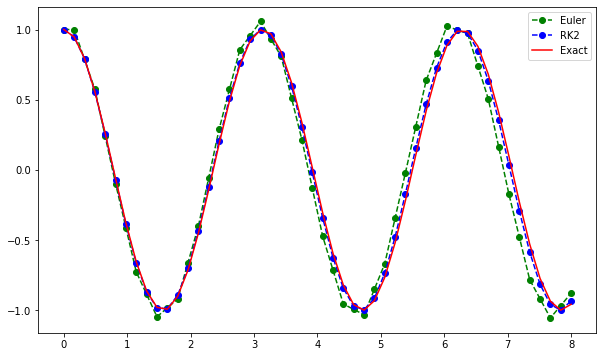

In [26]:
# Solution

# Redo the sine/cosine function with the RK method
# g(x,u,v) = -a**2 u, f(x,u,v) = v
# Apply this for Nx=50 (initially), xmax=8.0, and compare to previous case with the same parameters. 

Nx=50
xmin=0.0
xmax=8.0
x=np.linspace(xmin,xmax,Nx)


a=2.0
Afact=1.0

uf0=Afact
ud0=0.0

#Define the functions gf and ff. 
#These are called from within the Euler and RK functions. They need to have the
#same names as used in those functions.They need to have the same number of arguments.
#The variable names can be different.

def gf(x,uf,ud):
    A = 0.0
    B = - 4.0
    C = 0.0
    D = 0.0
    return A+B*uf+C*ud+D*ud*ud

def ff(x,uf,ud):
    return ud

# The "general" solution in terms of the boundary conditions
Aconst=ud0/a
Bconst=uf0
utrue=Aconst*np.sin(a*x)+Bconst*np.cos(a*x)

# Find the solution using Euler method

ufn=ode2_euler(Nx,xmin,xmax,uf0,ud0)

# Find the solution using the Runge-Kutta method

uf2f=ode2_rk2(Nx, xmin, xmax, uf0, ud0)

#Compare the solutions
fig = plt.figure(figsize=(10,6))
plt.plot(x,ufn,'go--', label="Euler")               
plt.plot(x,uf2f,'bo--', label="RK2")
plt.plot(x,utrue,'r-', label="Exact")
plt.legend()
plt.show()


___________________________________________________________________________________________________________________________

## Team Activity (link to your team's breakout room)

## Problem 2

In this problem you will solve the (simplified) equation of motion of a fast moving object encountering air resistance (which is proportional to the square of the object's speed). The equation of motion is of the form:

$$ m \frac{d^2x}{dt^2} + c \ (\frac{dx}{dt})^2 = 0$$

For $m=10$ and $c=1$ (all units are S.I.), find and plot the position $x(t)$ as a function of time $t$ for 20 seconds. The initial conditions are $x(0)=0$ and $\frac {dx}{dt}(0)=4$. In this lab, you will solve the above differential equation using the Euler and RK2 functions you have developed.

**Hint**: Use the approach used in the previous problem to solve this equation. You need to just set the proper constants (A, B, C, D) and the initial conditions for this problem.

**Important note on variables**: The Euler and RK methods were explained with the independent varaible $x$ and dependent variable $u$. In this problem, the independent variable is time $t$ and the dependent variable (the position) is $x$. In your code, you can continue using $x$ and $u$ or switch to $t$ and $x$.

In [27]:
# your code here


**Return to main room**

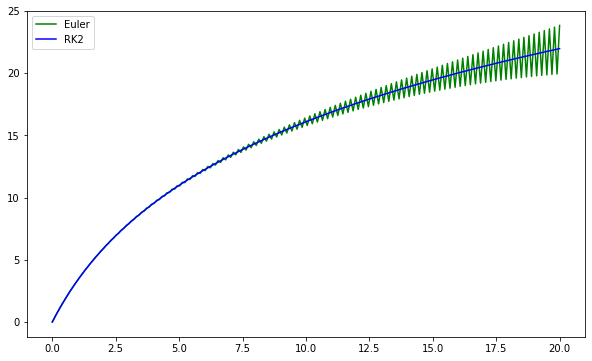

In [28]:
# Solution

Nx=200
xmin=0.0
xmax=20.0
t=np.linspace(xmin,xmax,Nx)

uf0=0.0
ud0=4.0

#Define the functions gf and ff

def gf(t,uf,ud):
    A = 0.0
    B = 0.0
    C = 0.0
    D = - 0.1
    return A+B*uf+C*ud+D*ud*ud

def ff(t,uf,ud):
    return ud

# Find the solution using Euler method

ufn=ode2_euler(Nx,xmin,xmax,uf0,ud0)

# Find the solution using the Runge-Kutta (2nd order) method

uf2f=ode2_rk2(Nx, xmin, xmax, uf0, ud0)

#Compare the solutions

# plt.plot(t,ufn,'g-', label="Euler")
fig = plt.figure(figsize=(10,6))
plt.plot(t,ufn,'g-', label="Euler")
plt.plot(t,uf2f,'b-', label="RK2")
plt.legend()
plt.show()

Euler's method is not performing well. More points (than the Nx = 200 used in this run) are needed for a better approximation.

___________________________________________________________________________________________________________________________

## The wave equation : extension to partial differential equations

The **wave equation** is a **second order partial differential equation** involving a second-order time derivative ($\frac {\partial^2 u}{\partial t^2}$) and second-order space derivatives (i.e. $\frac {\partial^2 u}{\partial x^2} $, $\frac {\partial^2 u}{\partial y^2} $). 

It describes a large number of wave phenomena (such as sound waves, water waves, elecromagnetic waves, seismic waves, etc.) It is and important equation in fields such as mechanics, electromagnetics, fluid dynamics, etc.  


### The one-dimensional (1D) wave equation (PDE):

In one dimension (1D) the wave equation is expressed as:
$$\frac {\partial^2 \psi}{\partial t^2} = v^2 \frac {\partial^2 \psi}{\partial x^2} $$

where $\psi = \psi (x, t)$ describes the value of the physical property we are studying in the spatial location $x$ at time $t$; $v$ is the propagation speed, a non-negative real coefficient. 

The function $\psi$ may describe displacement (e.g. in a travelling wave in a string), density of particles (in sound waves), etc. 

As shown in Lecture Notes, solution is $$\psi_{\pm} (x,t) = A \sin(\omega t \pm kx) \pm B\cos(\omega t \pm kx)$$ with $\frac {\omega}{k} = v$.

### Visualizing the $\frac {\omega}{k} = v$ relation

Plotting the x-dependence and the t-dependence of the solution $\psi = \sin (\omega t + k x)$. 

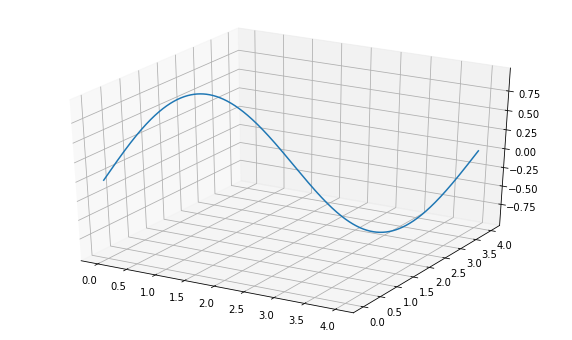

In [34]:
# %matplotlib notebook (to activate this magic command, uncomment and place at top of Notebook, and restart)

# plotting the x-dependence of the wave
omega = 0
kappa = np.pi/2

fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection='3d')

tline = np.linspace(0, 4, 1000)
xline = np.linspace(0, 4, 1000)
#yline = np.linspace(0, 4, 1000)
zline = np.sin(omega * tline + kappa * xline)

ax.plot3D(xline, tline, zline)
plt.show()

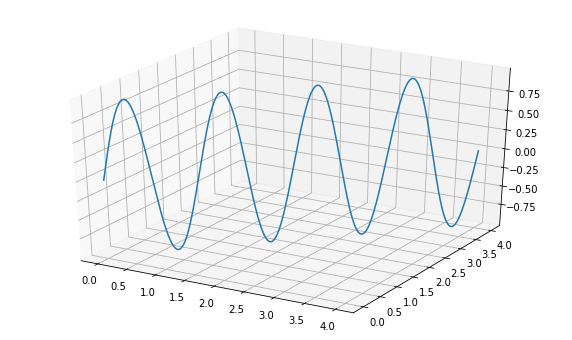

In [33]:
# plotting the t-dependence of the wave

omega = 2 * np.pi
kappa = 0

fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection='3d')

tline = np.linspace(0, 4, 1000)
xline = np.linspace(0, 4, 1000)
#yline = np.linspace(0, 4, 1000)
zline = np.sin(omega * tline + kappa * xline)

ax.plot3D(xline, tline, zline)
plt.show()
